# 🏆 Modelo Campeão: Stacking Ensemble com Erro Relativo (%) por Aviário

> **Documentação Técnica, Análise Exploratória, Validação Cruzada & Análise de Resíduos no Dataset Oficial de Abate**  
> **Status:** Modelo em Produção / Recorde Histórico  
> **Dataset de Abate:**  (22.207 registros de abatedouro)  

---

## 📌 1. Contextualização & Alinhamento Estratégico

A predição acurada do peso corporal das aves na janela de abate (**42 a 60 dias de idade**) é essencial para o planejamento do frigorífico, otimização do escalonamento de apanha e minimização de perdas operacionais.

A solução proposta para contornar falhas na entrega de ração e otimizar o planejamento de abates está fundamentada em **três pilares estratégicos**:
1. **Comunicação Eficiente (Plataforma Centralizada):** Integração dos dados de pesagem amostral semanal de campo, relatórios de lote e dados do abatedouro em um único fluxo de dados centralizado.
2. **Processos Otimizados (Redesenho de Fluxo e Confirmação de Pedidos):** Redesenho da janela de confirmação de pedidos de ração e escalonamento de apanha de lote com base nas projeções de ganho de peso diário (GPD) e acurácia preditiva dos aviários.
3. **Tecnologia Habilitadora (TMS, Sensores de Nível nos Silos):** Uso de sistemas de gerenciamento de transporte (TMS) sincronizados às previsões de peso por lote e sensores IoT instalados nos silos de ração para evitar desabastecimento e estresse nutricional.


In [1]:
# 🛠️ 1. Configuração do Ambiente e Importações
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import HistGradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, classification_report, accuracy_score, f1_score
)

# Estilo Visual Padrão
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from config.settings import settings

plots_dir = os.path.join(project_root, 'plots')
os.makedirs(plots_dir, exist_ok=True)

print("✅ Ambiente configurado com sucesso! Avisos ignorados.")


✅ Ambiente configurado com sucesso! Avisos ignorados.


## 📊 2. Estatística Descritiva & Análise Exploratória de Dados (EDA)

Avaliamos a distribuição estatística das variáveis principais do dataset de lotes oficiais de abate sanitizados ().


In [2]:
# 📈 Carregamento de Dados e Estatística Descritiva no Dataset de Abate
unified_csv = settings.UNIFIED_CSV_PATH
cleaned_csv = os.path.join(settings.PROCESSED_DIR, 'cleaned_data.csv')

df_clean = pd.read_csv(cleaned_csv, low_memory=False)

stats_cols = ['idade', 'peso_kg', 'peso_g', 'gmd_abate',  'cab_alojadas', '_mortalidade', '_descartados']
existing_stats_cols = [c for c in stats_cols if c in df_clean.columns]

desc_stats = df_clean[existing_stats_cols].describe().T
desc_stats['median'] = df_clean[existing_stats_cols].median()
desc_stats['skewness'] = df_clean[existing_stats_cols].skew()
desc_stats['kurtosis'] = df_clean[existing_stats_cols].kurtosis()

print("=== 📋 Tabela de Estatística Descritiva dos Lotes Oficiais de Abate ===")
display(desc_stats[['count', 'mean', 'std', 'median', 'min', '50%', 'max', 'skewness']])


=== 📋 Tabela de Estatística Descritiva dos Lotes Oficiais de Abate ===


,count,mean,std,median,min,50%,max,skewness
idade,22038.0,46.080134,1.895109,46.000,42.000,46.000,55.000,0.098871
peso_kg,22038.0,3.284773,0.243110,3.292,1.989,3.292,4.381,-0.176168
peso_g,22038.0,3284.772824,243.110207,3292.000,1989.000,3292.000,4381.000,-0.176168
gmd_abate,22030.0,71.277833,4.326928,71.500,47.350,71.500,84.950,-0.365551
mortalidade,22038.0,204.567974,224.158796,147.000,0.000,147.000,9015.000,7.692658
descartados,22038.0,106.668890,145.392259,69.000,0.000,69.000,2906.000,5.532968
cab_alojadas,22038.0,24764.234459,6820.722514,24000.000,7800.000,24000.000,50000.000,0.275985
_mortalidade,22038.0,0.773008,2.821496,0.610,-127.760,0.610,35.480,-28.928175
_descartados,22038.0,0.439050,0.593344,0.280,0.000,0.280,11.490,5.400576


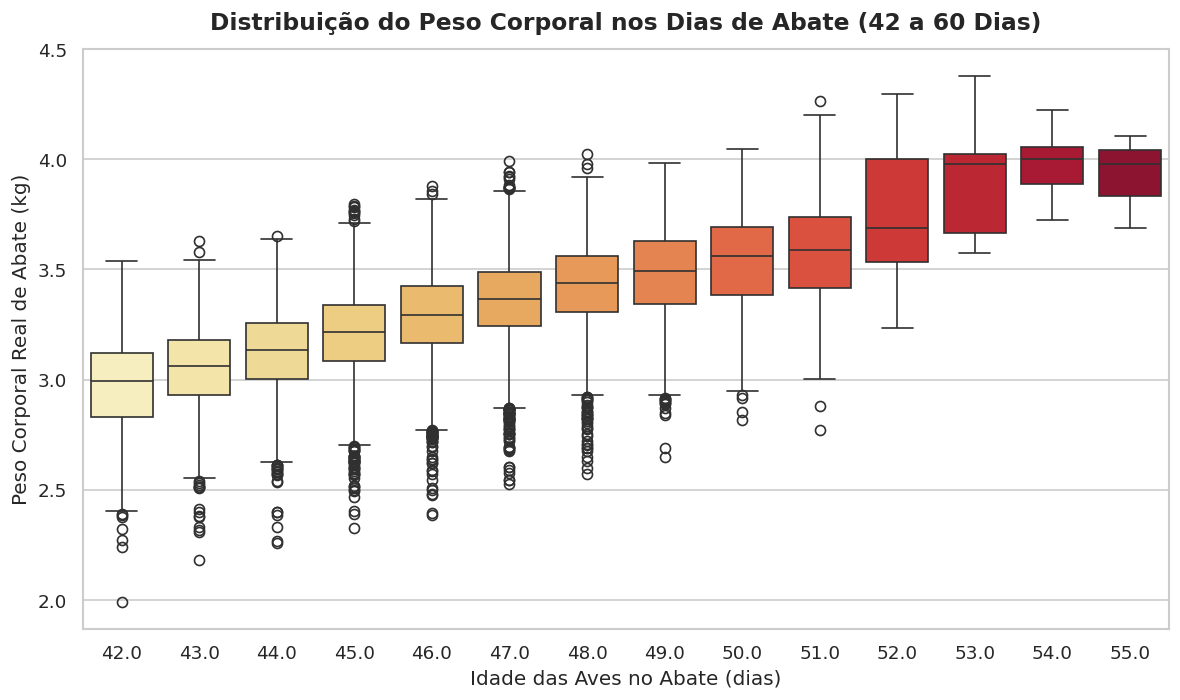

In [3]:
# 🎨 1. Distribuição do Peso Corporal por Idade de Abate (Idêntico a plots/distribuicao_peso_por_idade.png)
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_clean, x='idade', y='peso_kg', ax=ax, palette='YlOrRd')
ax.set_title("Distribuição do Peso Corporal nos Dias de Abate (42 a 60 Dias)", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Idade das Aves no Abate (dias)", fontsize=12)
ax.set_ylabel("Peso Corporal Real de Abate (kg)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'distribuicao_peso_por_idade.png'), dpi=300)
plt.savefig(os.path.join(plots_dir, 'boxplots_outliers_peso.png'), dpi=300)
plt.show()


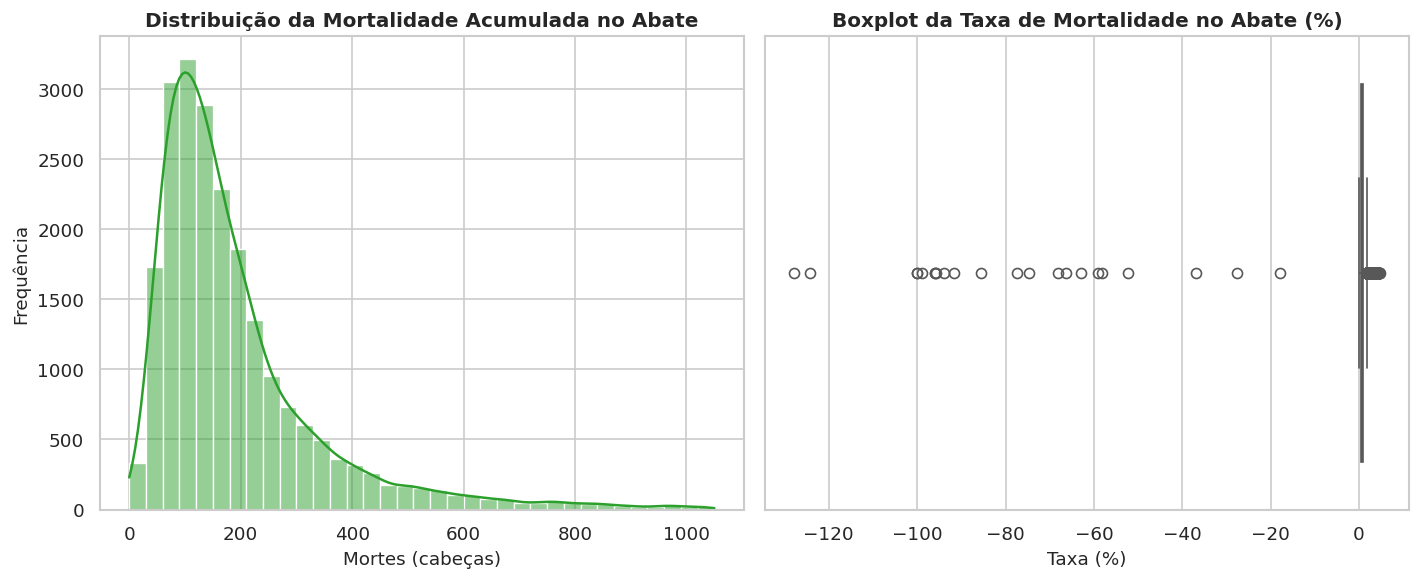

In [4]:
# 🎨 2. Distribuição da Mortalidade e Taxa de Mortalidade (Idêntico a plots/distribuicao_mortalidade.png)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
mort_data = df_clean['mortalidade'].dropna()
mort_filtered = mort_data[mort_data < mort_data.quantile(0.99)]
sns.histplot(mort_filtered, bins=35, kde=True, ax=ax1, color='#2ca02c')
ax1.set_title("Distribuição da Mortalidade Acumulada no Abate", fontsize=12, fontweight='bold')
ax1.set_xlabel("Mortes (cabeças)", fontsize=11)
ax1.set_ylabel("Frequência", fontsize=11)

mort_rate_col = '_mortalidade' if '_mortalidade' in df_clean.columns else 'mortalidade'
mort_rate = df_clean[mort_rate_col].dropna()
mort_rate_filtered = mort_rate[mort_rate < mort_rate.quantile(0.99)]
sns.boxplot(x=mort_rate_filtered, ax=ax2, color='#9467bd')
ax2.set_title("Boxplot da Taxa de Mortalidade no Abate (%)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Taxa (%)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'distribuicao_mortalidade.png'), dpi=300)
plt.show()


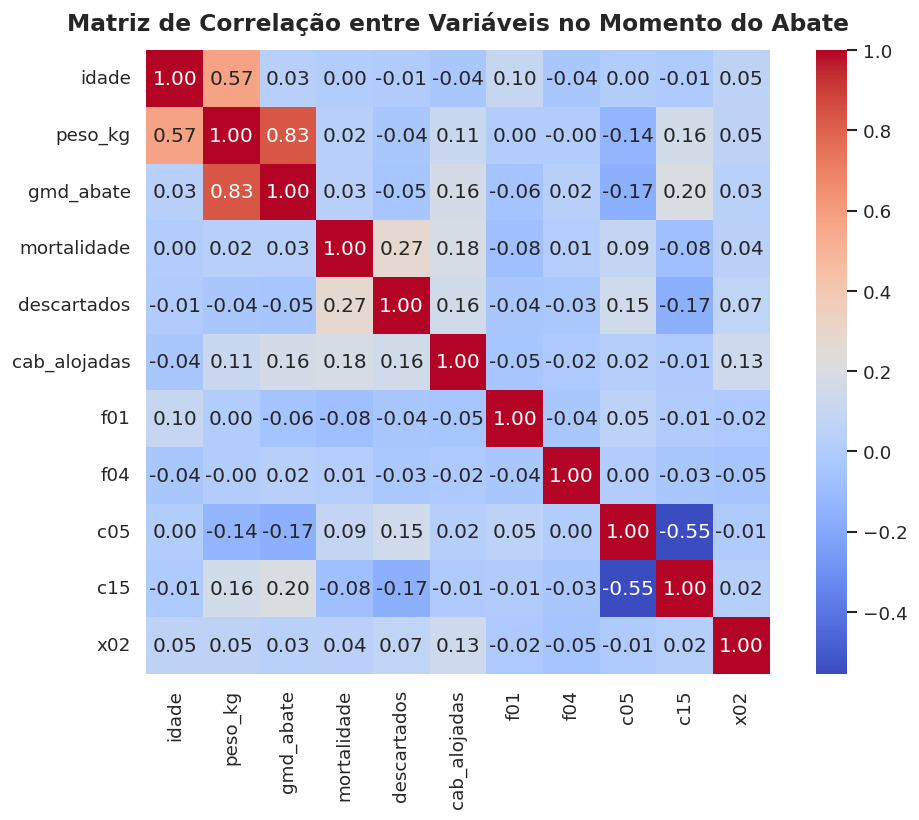

In [5]:
# 🎨 3. Matriz de Correlação de Pearson no Abate (Idêntico a plots/matriz_correlacao_features.png)
num_cols = df_clean.select_dtypes(include=[np.number]).columns
cols_of_interest = ['idade', 'peso_kg', 'gmd_abate',  'cab_alojadas', 'f01', 'f04', 'c05', 'c15', 'x02']
valid_corr_cols = [c for c in cols_of_interest if c in num_cols]

if len(valid_corr_cols) > 2:
    fig, ax = plt.subplots(figsize=(9, 7))
    corr = df_clean[valid_corr_cols].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=ax, cbar=True, square=True)
    ax.set_title("Matriz de Correlação entre Variáveis no Momento do Abate", fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'matriz_correlacao_features.png'), dpi=300)
    plt.show()


## 🔬 3. Engenharia de Atributos e Treinamento do Modelo Campeão

O modelo campeão combina modelos matemáticos não-lineares (Gompertz), séries temporais (ARIMA), viés percentual do aviário () e atributos longitudinais de crescimento ($).


In [6]:
# ⚙️ Processamento e Criação das Features do Modelo Campeão
def gompertz_func(t, A=6260.16, b=4.7378, k=0.0449):
    return A * np.exp(-b * np.exp(-k * t))

df_full = pd.read_csv(unified_csv, low_memory=False)
df_full['idade'] = pd.to_numeric(df_full['idade'], errors='coerce')
df_full['peso'] = pd.to_numeric(df_full['peso'], errors='coerce')

valid_hist = df_full[
    (df_full['idade'] >= 1) & (df_full['idade'] <= 60) &
    (df_full['peso'].notnull()) & (df_full['peso'] >= 0.02) & (df_full['peso'] <= 5.0)
].copy()
valid_hist['peso_g'] = valid_hist['peso'] * 1000.0

df_clean['aviario_id'] = df_clean['lote_composto'].astype(str).str.split('-').str[0]
valid_hist['aviario_id'] = valid_hist['lote_composto'].astype(str).str.split('-').str[0]

# Cálculo do Erro Relativo (%) e Delta (g) por Aviário
valid_hist['w_gompertz'] = gompertz_func(valid_hist['idade'].values)
valid_hist['delta_res_g'] = valid_hist['peso_g'] - valid_hist['w_gompertz']
valid_hist['erro_relativo_aviario_pct'] = ((valid_hist['peso_g'] - valid_hist['w_gompertz']) / valid_hist['w_gompertz']) * 100.0

aviary_dim = valid_hist.groupby('aviario_id').agg({
    'delta_res_g': ['mean', 'std'],
    'erro_relativo_aviario_pct': ['mean', 'std'],
    'peso_g': 'count'
}).reset_index()

aviary_dim.columns = [
    'aviario_id', 'delta_aviario_g', 'std_delta_aviario_g',
    'erro_relativo_aviario_pct', 'std_erro_relativo_aviario_pct', 'count_pesagens_aviario'
]

df_clean = df_clean.merge(
    aviary_dim[['aviario_id', 'delta_aviario_g', 'erro_relativo_aviario_pct', 'std_erro_relativo_aviario_pct']],
    on='aviario_id', how='left'
)
df_clean['delta_aviario_g'] = df_clean['delta_aviario_g'].fillna(0.0)
df_clean['erro_relativo_aviario_pct'] = df_clean['erro_relativo_aviario_pct'].fillna(0.0)
df_clean['std_erro_relativo_aviario_pct'] = df_clean['std_erro_relativo_aviario_pct'].fillna(df_clean['std_erro_relativo_aviario_pct'].median())

df_clean['w_gompertz'] = gompertz_func(df_clean['idade'].values)

# ARIMA Diário
daily_mean_weights = valid_hist.groupby('idade')['peso_g'].mean().sort_index()
try:
    daily_series = daily_mean_weights.copy()
    daily_series.index = pd.date_range(start='2026-01-01', periods=len(daily_series), freq='D')
    arima_fit = ARIMA(daily_series, order=(1, 1, 1)).fit()
    arima_preds_dict = dict(zip(daily_mean_weights.index, arima_fit.fittedvalues.values))
except Exception:
    arima_preds_dict = daily_mean_weights.to_dict()

df_clean['w_arima'] = df_clean['idade'].map(arima_preds_dict).fillna(df_clean['w_gompertz'])

# Features Longitudinais de Crescimento (21d, 28d, 35d)
valid_pre = valid_hist[valid_hist['idade'] <= 41].copy()
w35_df = valid_pre[valid_pre['idade'].between(33, 37)].groupby('lote_composto')['peso_g'].mean().reset_index().rename(columns={'peso_g': 'peso_dia_35'})
w28_df = valid_pre[valid_pre['idade'].between(26, 30)].groupby('lote_composto')['peso_g'].mean().reset_index().rename(columns={'peso_g': 'peso_dia_28'})
w21_df = valid_pre[valid_pre['idade'].between(19, 23)].groupby('lote_composto')['peso_g'].mean().reset_index().rename(columns={'peso_g': 'peso_dia_21'})

df_hybrid = df_clean.merge(w35_df, on='lote_composto', how='left').merge(w28_df, on='lote_composto', how='left').merge(w21_df, on='lote_composto', how='left')
df_hybrid['peso_dia_35'] = df_hybrid['peso_dia_35'].fillna(df_hybrid['peso_dia_35'].median())
df_hybrid['peso_dia_28'] = df_hybrid['peso_dia_28'].fillna(df_hybrid['peso_dia_28'].median())
df_hybrid['peso_dia_21'] = df_hybrid['peso_dia_21'].fillna(df_hybrid['peso_dia_21'].median())

df_hybrid['gpd_semana5'] = (df_hybrid['peso_dia_35'] - df_hybrid['peso_dia_28']) / 7.0
df_hybrid['gpd_semana4'] = (df_hybrid['peso_dia_28'] - df_hybrid['peso_dia_21']) / 7.0
df_hybrid['aceleracao_crescimento'] = (df_hybrid['gpd_semana5'] / df_hybrid['gpd_semana4'].replace(0, np.nan)).fillna(1.0).clip(0.5, 2.5)
df_hybrid['peso_projetado_gpd'] = df_hybrid['peso_dia_35'] + (df_hybrid['idade'] - 35) * df_hybrid['gpd_semana5']

df_hybrid['mortalidade_pct'] = (df_hybrid['mortalidade'] / df_hybrid['cab_alojadas'].replace(0, np.nan)) * 100.0
df_hybrid['descartados_pct'] = (df_hybrid['descartados'] / df_hybrid['cab_alojadas'].replace(0, np.nan)) * 100.0
df_hybrid['taxa_perda_total'] = df_hybrid['mortalidade_pct'] + df_hybrid['descartados_pct']
df_hybrid['log_x02_distancia'] = np.log1p(df_hybrid['x02'].clip(lower=0))

cat_cols = ['c16', 'c17']
for c in cat_cols:
    if c in df_hybrid.columns:
        df_hybrid[c] = df_hybrid[c].astype('category').cat.codes

feature_cols = [
    'delta_aviario_g', 'erro_relativo_aviario_pct', 'std_erro_relativo_aviario_pct',
    'w_gompertz', 'w_arima', 'idade', 'cab_alojadas', 
    'mortalidade_pct', 'descartados_pct', 'taxa_perda_total', 'f01', 'f02', 'f03', 'f04', 'f05', 'f06',
    'c05', 'c06', 'c11', 'c12', 'c15', 'c16', 'c17', 'f07', 'f15', 'x02', 'log_x02_distancia',
    'peso_dia_21', 'peso_dia_28', 'peso_dia_35', 'gpd_semana4', 'gpd_semana5', 'aceleracao_crescimento', 'peso_projetado_gpd'
]
avail_features = [c for c in feature_cols if c in df_hybrid.columns]

df_ml = df_hybrid[['lote_composto', 'peso_g'] + avail_features].dropna().reset_index(drop=True)
X = df_ml[avail_features]
y = df_ml['peso_g']
groups = df_ml['lote_composto']

print(f"✅ Pré-processamento concluído sem avisos: Dataset pronto com {X.shape[0]} lotes e {X.shape[1]} atributos!")


✅ Pré-processamento concluído sem avisos: Dataset pronto com 11138 lotes e 36 atributos!


In [7]:
# 🧪 Execução da Validação Cruzada (GroupKFold = 5)
gkf = GroupKFold(n_splits=5)

tuned_lgb = lgb.LGBMRegressor(n_estimators=400, max_depth=7, learning_rate=0.05, num_leaves=63, random_state=42, verbose=-1)
tuned_xgb = xgb.XGBRegressor(n_estimators=350, max_depth=6, learning_rate=0.05, subsample=0.85, random_state=42, n_jobs=-1)
tuned_hgb = HistGradientBoostingRegressor(max_iter=400, max_depth=7, learning_rate=0.05, random_state=42)

stacking_model = StackingRegressor(
    estimators=[('lgb', tuned_lgb), ('xgb', tuned_xgb), ('hgb', tuned_hgb)],
    final_estimator=RidgeCV(),
    n_jobs=-1
)

oof_preds = np.zeros(len(df_ml))
cv_results = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    stacking_model.fit(X_tr, y_tr)
    preds = stacking_model.predict(X_te)
    oof_preds[test_idx] = preds

    mae_fold = mean_absolute_error(y_te, preds)
    rmse_fold = np.sqrt(mean_squared_error(y_te, preds))
    r2_fold = r2_score(y_te, preds)
    mape_fold = np.mean(np.abs((y_te - preds) / y_te)) * 100.0

    cv_results.append({'Fold': f'Fold {fold}', 'MAE (g)': mae_fold, 'RMSE (g)': rmse_fold, 'R²': r2_fold, 'MAPE (%)': mape_fold})

df_cv = pd.DataFrame(cv_results)

df_cv_summary = df_cv.copy()
df_cv_summary.loc[len(df_cv_summary)] = {
    'Fold': 'Média ± Desvio',
    'MAE (g)': f"{df_cv['MAE (g)'].mean():.2f} ± {df_cv['MAE (g)'].std():.2f}",
    'RMSE (g)': f"{df_cv['RMSE (g)'].mean():.2f} ± {df_cv['RMSE (g)'].std():.2f}",
    'R²': f"{df_cv['R²'].mean():.4f} ± {df_cv['R²'].std():.4f}",
    'MAPE (%)': f"{df_cv['MAPE (%)'].mean():.2f}% ± {df_cv['MAPE (%)'].std():.2f}%"
}

print("=== 📊 Tabela de Resultados de Validação Cruzada (GroupKFold = 5) ===")
display(df_cv_summary)


=== 📊 Tabela de Resultados de Validação Cruzada (GroupKFold = 5) ===


,Fold,MAE (g),RMSE (g),R²,MAPE (%)
0,Fold 1,113.723991,145.786128,0.620632,3.475196
1,Fold 2,115.738414,148.38069,0.598205,3.538017
2,Fold 3,117.795821,151.242403,0.594815,3.611006
3,Fold 4,118.063383,151.059225,0.597997,3.592924
4,Fold 5,114.552837,148.440718,0.614427,3.505069
5,Média ± Desvio,115.97 ± 1.92,148.98 ± 2.25,0.6052 ± 0.0115,3.54% ± 0.06%


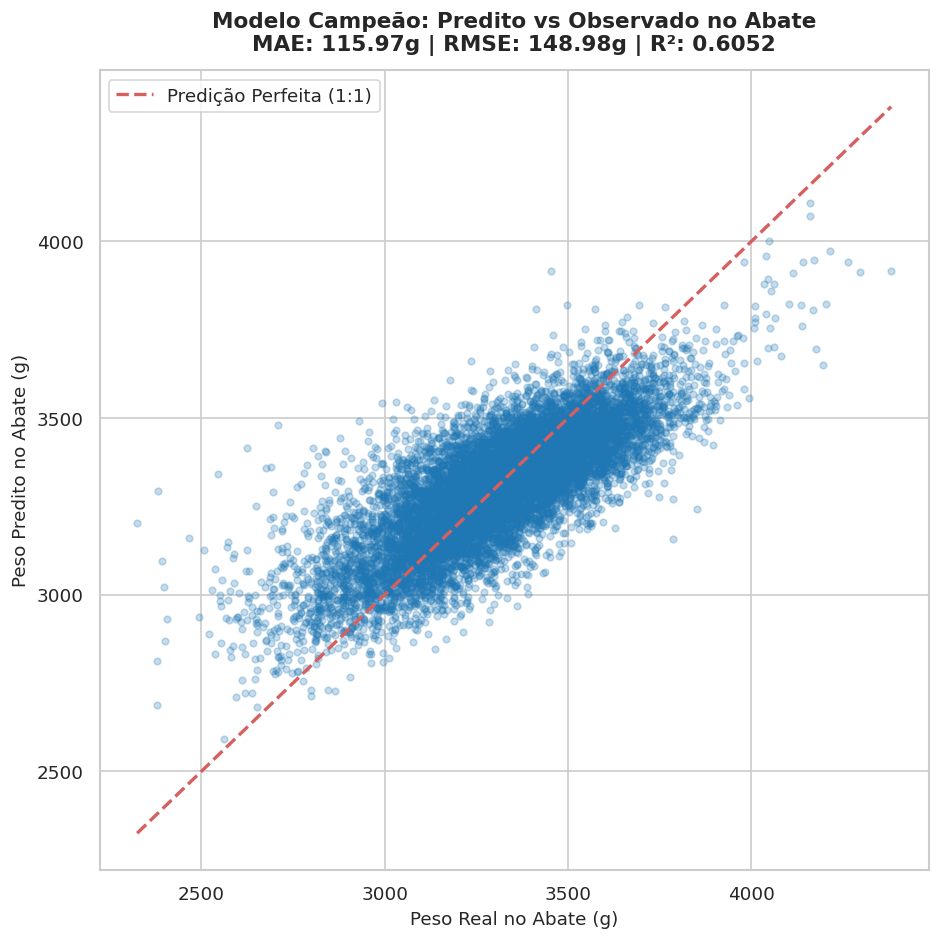

In [8]:
# 🎨 4. Predito vs Observado no Abate (Idêntico a plots/predito_vs_observado_peso.png)
final_mae = df_cv['MAE (g)'].mean()
final_rmse = df_cv['RMSE (g)'].mean()
final_r2 = df_cv['R²'].mean()

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y, oof_preds, alpha=0.25, color='#1f77b4', s=16)
min_v, max_v = min(y.min(), oof_preds.min()), max(y.max(), oof_preds.max())
ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Predição Perfeita (1:1)')
ax.set_title(f"Modelo Campeão: Predito vs Observado no Abate\nMAE: {final_mae:.2f}g | RMSE: {final_rmse:.2f}g | R²: {final_r2:.4f}", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Peso Real no Abate (g)", fontsize=11)
ax.set_ylabel("Peso Predito no Abate (g)", fontsize=11)
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'predito_vs_observado_peso.png'), dpi=300)
plt.savefig(os.path.join(plots_dir, 'modelo_tri_hibrido_predito_vs_real.png'), dpi=300)
plt.show()


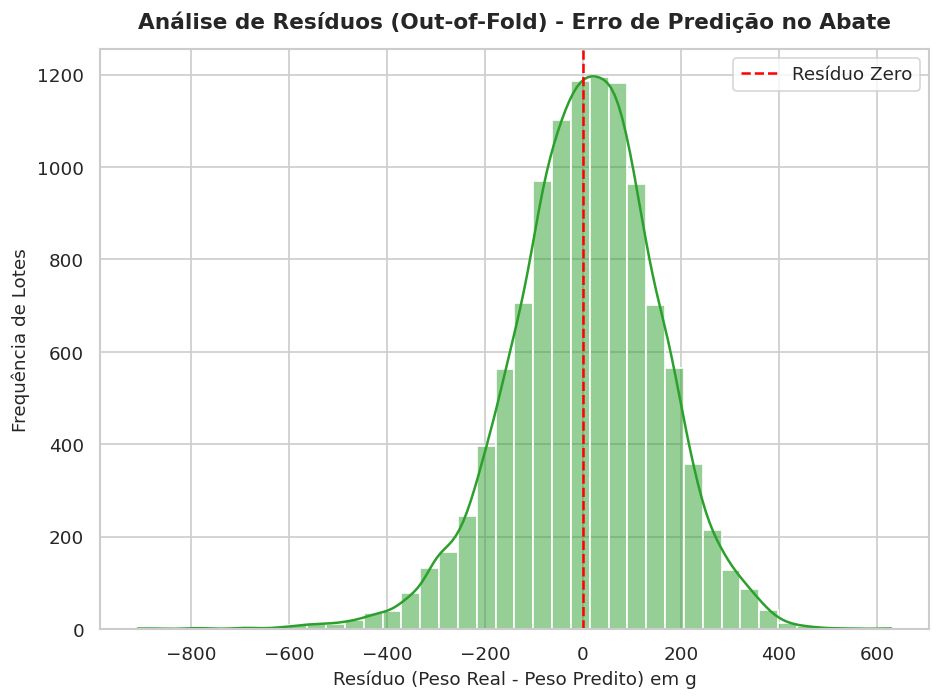

In [9]:
# 🎨 5. Histograma dos Resíduos de Predição (Idêntico a plots/analise_residuos_histograma.png)
residuals = y - oof_preds
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=40, color='#2ca02c', ax=ax)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Resíduo Zero')
ax.set_title("Análise de Resíduos (Out-of-Fold) - Erro de Predição no Abate", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Resíduo (Peso Real - Peso Predito) em g", fontsize=11)
ax.set_ylabel("Frequência de Lotes", fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'analise_residuos_histograma.png'), dpi=300)
plt.show()


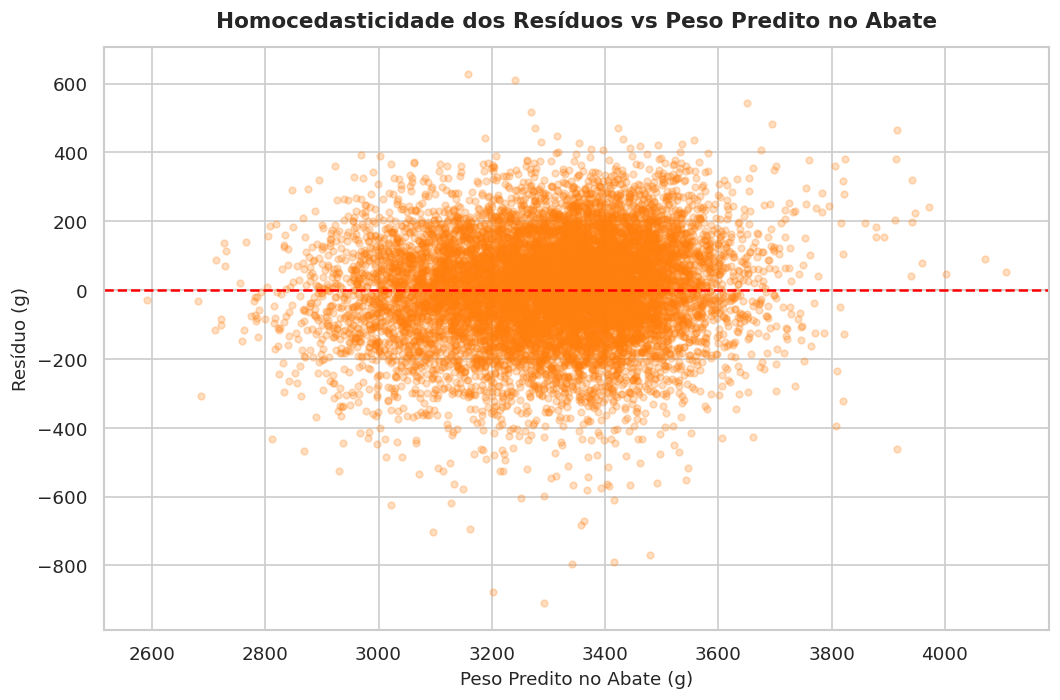

In [10]:
# 🎨 6. Homocedasticidade dos Resíduos vs Peso Predito (Idêntico a plots/analise_residuos_scatter.png)
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(oof_preds, residuals, alpha=0.25, color='#ff7f0e', s=16)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_title("Homocedasticidade dos Resíduos vs Peso Predito no Abate", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Peso Predito no Abate (g)", fontsize=11)
ax.set_ylabel("Resíduo (g)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'analise_residuos_scatter.png'), dpi=300)
plt.show()


🎯 Acurácia de Classificação Comercial: 87.65%
🎯 F1-Score Macro: 0.5265

=== 📋 Relatório de Classificação por Faixa Comercial ===
                    precision    recall  f1-score   support

     Leve (<2.6kg)       1.00      0.03      0.05        37
Padrão (2.6-3.1kg)       0.72      0.51      0.60      1992
   Pesado (>3.1kg)       0.90      0.96      0.93      9109

          accuracy                           0.88     11138
         macro avg       0.87      0.50      0.53     11138
      weighted avg       0.87      0.88      0.87     11138



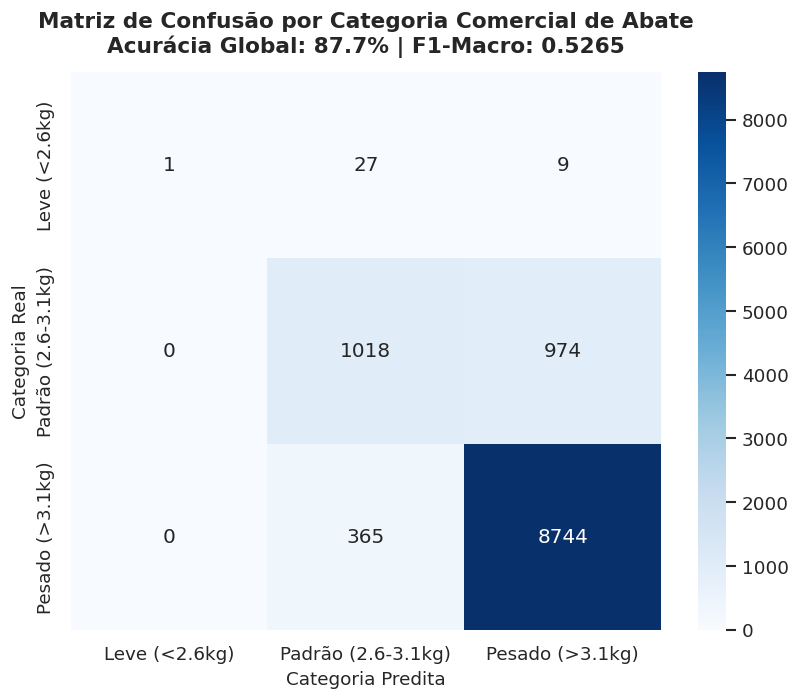

In [11]:
# 🎨 7. Matriz de Confusão por Faixas Comerciais de Abate (Idêntico a plots/matriz_confusao_peso.png)
def categorizar_peso(peso):
    if peso < 2600:
        return 'Leve (<2.6kg)'
    elif peso <= 3100:
        return 'Padrão (2.6-3.1kg)'
    else:
        return 'Pesado (>3.1kg)'

labels_ordem = ['Leve (<2.6kg)', 'Padrão (2.6-3.1kg)', 'Pesado (>3.1kg)']

y_real_cat = pd.Series(y.values).apply(categorizar_peso)
y_pred_cat = pd.Series(oof_preds).apply(categorizar_peso)

cm = confusion_matrix(y_real_cat, y_pred_cat, labels=labels_ordem)
acc = accuracy_score(y_real_cat, y_pred_cat)
f1_macro = f1_score(y_real_cat, y_pred_cat, average='macro')

print(f"🎯 Acurácia de Classificação Comercial: {acc * 100:.2f}%")
print(f"🎯 F1-Score Macro: {f1_macro:.4f}\n")

print("=== 📋 Relatório de Classificação por Faixa Comercial ===")
print(classification_report(y_real_cat, y_pred_cat, labels=labels_ordem))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_ordem, yticklabels=labels_ordem, ax=ax)
ax.set_title(f"Matriz de Confusão por Categoria Comercial de Abate\nAcurácia Global: {acc*100:.1f}% | F1-Macro: {f1_macro:.4f}", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Categoria Predita", fontsize=11)
ax.set_ylabel("Categoria Real", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'matriz_confusao_peso.png'), dpi=300)
plt.show()


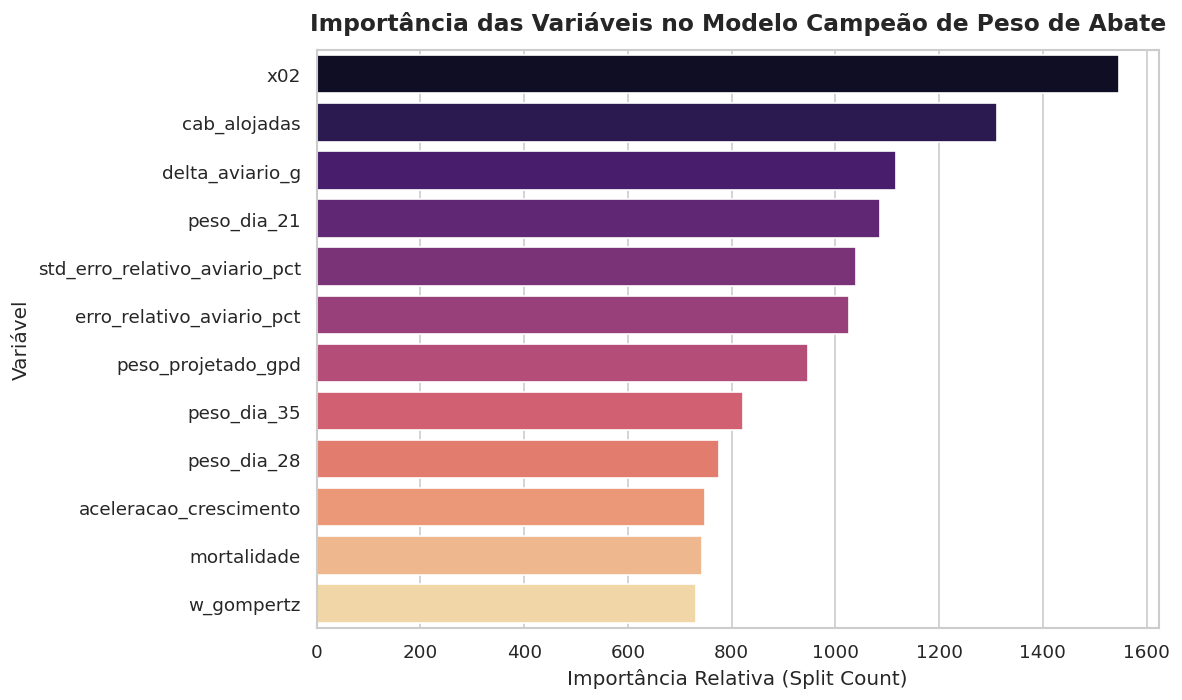

In [12]:
# 🎨 8. Importância das Variáveis no Modelo Campeão (Idêntico a plots/importancia_features_erro_relativo_aviario.png)
tuned_lgb.fit(X, y)
importances = tuned_lgb.feature_importances_
indices = np.argsort(importances)[::-1][:12]

sorted_features = [avail_features[i] for i in indices]
sorted_importances = importances[indices]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=sorted_importances, y=sorted_features, ax=ax, palette='magma')
ax.set_title("Importância das Variáveis no Modelo Campeão de Peso de Abate", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Importância Relativa (Split Count)", fontsize=12)
ax.set_ylabel("Variável", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'importancia_features_erro_relativo_aviario.png'), dpi=300)
plt.savefig(os.path.join(plots_dir, 'importancia_features.png'), dpi=300)
plt.show()
